<div style="background-color: black; color: BurlyWood ; padding: 10px; 
            font-size: 24px; border-radius: 5px; text-align: center;">
   Phân loại đa lớp cảnh vật tự nhiên sử dụng mô hình học sâu trên bộ dữ liệu Intel Image Classification 
</div>
<div style=" color: gray; padding: 10px; 
            font-size: 16px; border-radius: 5px; text-align: center;">
    Đồ án DL & Applications

</div>
<br>
<div style="color: gray;  text-align: center; font-size: 14px; margin-top: 10px;">
    <strong>Author:</strong> NCS Cáp Phạm Đình Thăng <br>
    <strong>Date:</strong> 2025 <br>
    
</div>

<div style="background-color: black; color: BurlyWood; padding: 15px;text-align: center; font-size: 20px; border-radius: 8px; font-weight: bold;">
                Import Necessary Libraries
</div>

In [1]:
#Các thư viện cần thiết
import os #đọc tạo thư mục, quản lý đường dẫn tập tin
import pandas as pd #thư viện làm việc với dữ liệu dạng bảng (dataframe, csv,...)
import numpy as np #thư viện toán học để xử lý dữ liệu số
import matplotlib.pyplot as plt #thư viện hỗ trợ vẽ biểu đồ
import seaborn as sns#hỗ trợ vẽ biểu đồ
from sklearn.model_selection import train_test_split #chia dữ liệu
from sklearn.metrics import confusion_matrix #dùng đánh giá mô hình phân loại, số lượng dự đoán đúng và sai
import tensorflow as tf #thư viện mã nguồn mở của Google dành cho deep learning
from tensorflow import keras #API của tensorflow để xây dựng mạng CNN
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
#Dense: lớp kết nối đầy đủ (fully connected layer) trong mạng CNN
#Conv2D: lớp tích chập dùng trong mạng CNN để xử lý ảnh
#Maxpooling2D: Lớp pooling giúp giảm kích thước của ảnh, giảm overfiting
#Flatten: Chuyển đổi tensor nhiều chiều thành vector 1 chiều.
#Dropout: Lớp giảm overfitting bằng cách loại bỏ ngẫu nhiên một số neuron trong quá trình huấn luyện
from tensorflow.keras.models import Sequential #Mô hình mạng tuần tự trong Keras
from tensorflow.keras.optimizers import Adamax #Thuật toán tối ưu adam dùng trong huấn luyện mô hình
from tensorflow.keras.callbacks import EarlyStopping #Giúp dừng huấn luyện sớm nếu mô hình không cải thiện sau một số epoch nhất định
from tensorflow.keras.applications import imagenet_utils
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.layers import BatchNormalization #Chuẩn hóa đầu ra của mỗi lớp để tăng tốc huấn luyện
from tqdm import tqdm #hiển thị thanh tiến trình khi chạy vòng lặp
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Tăng cường dữ liệu ảnh: xoay, lật, thay đổi độ sáng ...
from tensorflow.keras.applications import (
    VGG16, ResNet50, MobileNetV2, EfficientNetB0
)
from PIL import Image
import warnings
warnings.filterwarnings('ignore')
tf.config.list_physical_devices('GPU')

[]

<div style="background-color: black; color: BurlyWood; padding: 15px;text-align: center; font-size: 20px; border-radius: 8px; font-weight: bold;">
                Setting hyperparameters for model training  
</div>

<div style="background-color: black; color: BurlyWood; padding: 15px;text-align: center; font-size: 20px; border-radius: 8px; font-weight: bold;">
<p>Epoch: Là một lần duyệt toàn bộ tập dữ liệu của mô hình</p>
<p>Ví dụ: Tập dữ liệu có 10 000 ảnh</p>
<p>epoch = 1: Mô hình duyệt qua 10 000 ảnh đúng 1 lần</p>
<p>epoch = 10: mô hình duyệt qua 10 000 ảnh 10 lần</p>
<p>Epoch quá nhỏ mô hình có thể chưa học đủ dễ dẫn đến underfiting</p>
<p>Epoch quá lớn: mô hình có thể học quá kỹ dữ liệu huấn luyện dễ dẫn đến overfiting</p>
<p>Có thể dùng EarlyStopping để ngăn mô hình học quá mức</p>
</div>

In [2]:
batch_size = 32 #Số lượng mẫu dữ liệu được đưa vào mô hình trong một lần cập nhật trọng số
img_size = (224,224)
num_classes = 6

<div style="background-color: black; color: BurlyWood; padding: 15px;text-align: center; font-size: 20px; border-radius: 8px; font-weight: bold;">
               Load the Data
</div>

In [3]:
train_dir = './data/seg_train/seg_train'
pred_dir = './data/seg_pred/seg_pred'
test_dir = './data/seg_test/seg_test'

<div style="background-color: black; color: BurlyWood; padding: 15px;text-align: center; font-size: 20px; border-radius: 8px; font-weight: bold;">
                Preparing training data: collecting file paths and corresponding labels  

</div>

In [8]:
filepaths_train= []
label_train = []
folds = os.listdir(train_dir)
for fold in folds:
    foldpath = os.path.join(train_dir,fold)
    files = os.listdir(foldpath)
    for file in tqdm(files):
        filepath = os.path.join(foldpath,file)
        filepaths_train.append(filepath)
        label_train.append(fold)

100%|██████████████████████████████████████████████████████████████████████████| 2382/2382 [00:00<00:00, 279917.97it/s]


In [9]:
len(filepaths_train)

14034

<div style="background-color: black; color: BurlyWood; padding: 15px;text-align: center; font-size: 20px; border-radius: 8px; font-weight: bold;">
                Creating a DataFrame to organize training data And Analysis

</div>

In [10]:
df_train = pd.DataFrame(
    {
        'filepath_train': filepaths_train,
        'label_train': label_train
    }
)

In [11]:
df_train.head()

,filepath_train,label_train
0,./data/seg_train/seg_train\buildings\0.jpg,buildings
1,./data/seg_train/seg_train\buildings\10006.jpg,buildings
2,./data/seg_train/seg_train\buildings\1001.jpg,buildings
3,./data/seg_train/seg_train\buildings\10014.jpg,buildings
4,./data/seg_train/seg_train\buildings\10018.jpg,buildings


In [12]:
df_train.sample(5)


,filepath_train,label_train
13575,./data/seg_train/seg_train\street\6393.jpg,street
4380,./data/seg_train/seg_train\forest\9419.jpg,forest
3866,./data/seg_train/seg_train\forest\534.jpg,forest
12096,./data/seg_train/seg_train\street\13226.jpg,street
7719,./data/seg_train/seg_train\mountain\16246.jpg,mountain


<div style="background-color: black; color: BurlyWood; padding: 15px;text-align: center; font-size: 20px; border-radius: 8px; font-weight: bold;">
            Visualizing the distribution of training data across different classes  

</div>

In [13]:
color = ['#FFE1FF','#E4B1F0','#7E60BF','#433878']

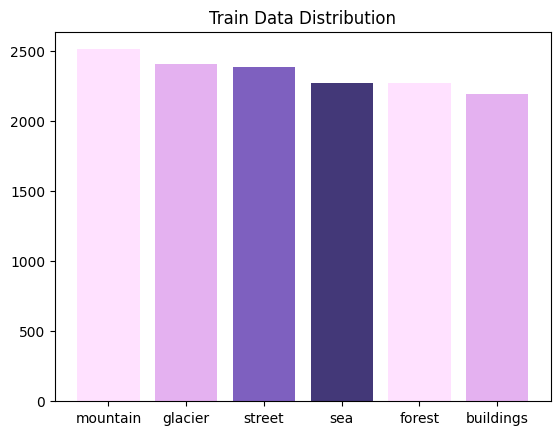

In [14]:
plt.bar(df_train['label_train'].value_counts().index,df_train['label_train'].value_counts(),color=color)
plt.title('Train Data Distribution')
plt.show()


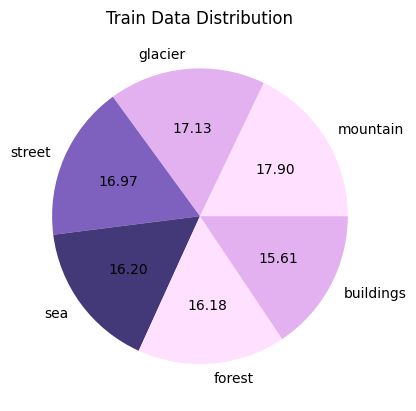

In [15]:
plt.pie(df_train['label_train'].value_counts(),labels=df_train['label_train'].value_counts().index,colors=color,autopct='%.2f')
plt.title('Train Data Distribution')
plt.show()

In [16]:
print(df_train['label_train'].value_counts())

label_train
mountain     2512
glacier      2404
street       2382
sea          2274
forest       2271
buildings    2191
Name: count, dtype: int64


In [17]:
print(f'this data has {df_train.shape[0]} rows and {df_train.shape[1]} columns')

this data has 14034 rows and 2 columns


<div style="background-color: black; color: BurlyWood; padding: 15px;text-align: center; font-size: 20px; border-radius: 8px; font-weight: bold;">
                 Preparing test data: collecting file paths and corresponding labels  

</div>

In [18]:
filepaths_test= []
label_test = []
folds = os.listdir(test_dir)
for fold in folds:
    foldpath = os.path.join(test_dir,fold)
    files = os.listdir(foldpath)
    for file in tqdm(files):
        filepath = os.path.join(foldpath,file)
        filepaths_test.append(filepath)
        label_test.append(fold)

100%|████████████████████████████████████████████████████████████████████████████| 501/501 [00:00<00:00, 501275.36it/s]


In [19]:
len(filepaths_test)

3000

<div style="background-color: black; color: BurlyWood; padding: 15px;text-align: center; font-size: 20px; border-radius: 8px; font-weight: bold;">
Creating a DataFrame to organize testing  data And Analysis</div>

In [20]:
df_test = pd.DataFrame(
    {
        'filepath_test': filepaths_test,
        'label_test': label_test
    }
)

In [21]:
df_test.head()

,filepath_test,label_test
0,./data/seg_test/seg_test\buildings\20057.jpg,buildings
1,./data/seg_test/seg_test\buildings\20060.jpg,buildings
2,./data/seg_test/seg_test\buildings\20061.jpg,buildings
3,./data/seg_test/seg_test\buildings\20064.jpg,buildings
4,./data/seg_test/seg_test\buildings\20073.jpg,buildings


In [22]:
df_test.sample(5)

,filepath_test,label_test
1585,./data/seg_test/seg_test\mountain\21085.jpg,mountain
305,./data/seg_test/seg_test\buildings\22987.jpg,buildings
839,./data/seg_test/seg_test\forest\23723.jpg,forest
1258,./data/seg_test/seg_test\glacier\22836.jpg,glacier
687,./data/seg_test/seg_test\forest\22446.jpg,forest


In [23]:
df_test.shape

(3000, 2)

<div style="background-color: black; color: BurlyWood; padding: 15px;text-align: center; font-size: 20px; border-radius: 8px; font-weight: bold;">
            Visualizing the distribution of testing data across different classes  

</div>

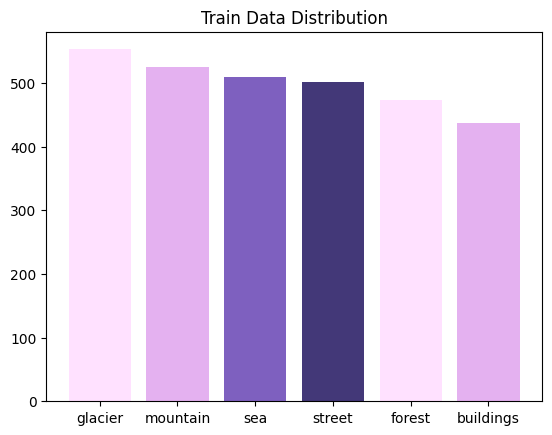

In [24]:
plt.bar(df_test['label_test'].value_counts().index,df_test['label_test'].value_counts(),color=color)
plt.title('Train Data Distribution')
plt.show()

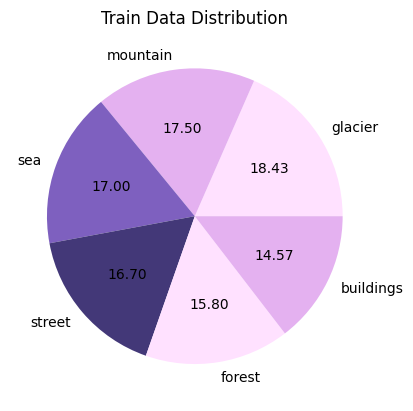

In [25]:
plt.pie(df_test['label_test'].value_counts(),labels=df_test['label_test'].value_counts().index,colors=color,autopct='%.2f')
plt.title('Train Data Distribution')
plt.show()

In [26]:
print(df_test['label_test'].value_counts())

label_test
glacier      553
mountain     525
sea          510
street       501
forest       474
buildings    437
Name: count, dtype: int64


In [27]:
print(f'this data has {df_test.shape[0]} rows and {df_test.shape[1]} columns')

this data has 3000 rows and 2 columns


<div style="background-color: black; color: BurlyWood; padding: 15px;text-align: center; font-size: 20px; border-radius: 8px; font-weight: bold;">
                 Generating batches of image data for training, validation, and testing  

</div>

In [4]:
#Đọc ảnh từ các thư mục con
#Gán nhãn đúng theo tên thư mục
#Áp dụng augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    subset='training',
    class_mode='categorical'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical'
)

#Test set không có augmentation vì cần đánh giá mô hình trên dữ liệu thật không biến đổi
#shuffle=False giữ nguyên thứ tự ảnh để dễ đối chiếu kết quả
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


<div style="background-color: black; color: BurlyWood; padding: 15px;text-align: center; font-size: 20px; border-radius: 8px; font-weight: bold;">
                 Build model

</div>